# Chương 3. HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH

## 1. Hiện tượng Overfitting trong quá trình huấn luyện
Học sinh “học tủ” có thể đạt điểm cao khi trúng đề nhưng vận dụng thực tế lại kém vì thiếu tính tổng quát. Mô hình cũng vậy: nếu chỉ “ghi nhớ” dữ liệu huấn luyện, nó sẽ dự đoán tốt trên tập này nhưng thất bại trên dữ liệu mới. Đây chính là hiện tượng overfitting trong quá trình huấn luyện thường gặp trong các mô hình học sâu có số lượng tham số phực tạp.

Overfitting thường xảy ra khi:
- Mô hình phức tạp trên mức cần thiết so với dữ liệu huấn luyện thường hay gặp trong các mô hình học sâu do kiến trúc phức tạp.
- Dữ liệu huấn luyện quá ít hay các đặc trưng khác biệt hoàn toàn so với dữ liệu thực tế.
- Dữ liệu chứa nhiều điểm nhiễu và không được xử lý tốt trước khi huấn luyện khiến cho mô hình học trên dữ liệu không đúng với thực tế.


### 1.1 Phương pháp L1 Regularization
Phương pháp L1 Regularization (hay Lasso Regularization) giúp tạo ra các tham số có giá trị bằng 0 (hay sparse weights) khi chúng có vai trò không quan trọng trong mô hình,  phù hợp với loại dữ liệu có nhiều đặc trưng dư thừa. Công thức của L1 Regularization  sau khi điều chỉnh hàm mất mát được viết lại thành:
\begin{equation}
  J_{L1}(\theta)  = \mathcal{L}(\theta) +\lambda\sum_{j=1}^{m}|\theta_j|
\end{equation}
Trong đó:
- $J_{L1}(\theta)$ hàm mất mát sau khi điều chỉnh.
- $\mathcal{L}(\theta)$ hàm mất mát ban đầu trước khi điều chỉnh.
- $\lambda$ hệ số điều chỉnh (regularization parameter) không âm.
- $m$ số lượng tham số trong mô hình cần huấn luyện.
- $\theta_i$ tham số huấn luyện thứ $i$ trong mô hình cần tối ưu.

In [7]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# Xây dựng mô hình có L1 regularization
# Hệ số điều chỉnh: 1e-4
model = keras.Sequential([
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l1(1e-4)), 
    layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l1(1e-4)),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


### 1.2 Phương pháp L2 Regularization
Phương pháp L2 Regularization (hay Ridge Regularization) tương tự như L1 tuy nhiên  L2 thay thế $\lambda\sum_{i=1}^{n}|\theta_i|$ thành $\lambda\sum_{i=1}^{n}\theta_i^2$ và có xu hướng điều chỉnh các tham số không quan trọng trong mô hình về giá trị rất nhỏ thay vì bằng 0 như L1 với công thức:
\begin{equation}
J_{L2}(\theta)  = \mathcal{L}(\theta) +\lambda\sum_{j=1}^{m}\theta_j^2
\end{equation}
Trong đó:
- $J_{L2}(\theta)$ hàm mất mát sau khi điều chỉnh.
- $\mathcal{L}(\theta)$ hàm mất mát ban đầu trước khi điều chỉnh.
- $\lambda$ hệ số điều chỉnh (regularization parameter) không âm.
- $m$ số lượng tham số trong mô hình cần huấn luyện.
- $\theta_i$ tham số huấn luyện thứ $i$ trong mô hình cần tối ưu.

In [8]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# Xây dựng mô hình có L2 regularization
# Hệ số điều chỉnh: 1e-4
model = keras.Sequential([
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4)), 
    layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


### 1.3 Phương pháp L1 + L2 Regularization
Như vậy ở L1 và L2 mỗi phương pháp đều có đặc trưng riêng biệt. L1 có khả năng loại bỏ các đặc trưng không quan trọng bằng cách đưa các giá trị tham số huấn luyện về 0, còn L2 có thể giảm giá trị tham số về một giá trị rất bé tiệm cận với 0. Cả hai phương pháp này đều đóng vai trò kiềm hãm sự biến động quá lớn của các tham số huấn luyện dẫn đến hiện tượng overfitting.  Phương pháp Elastic Net là sự kết hợp giữa L1 và L2 giúp cân bằng nhưng hạn chế của hai phương pháp này được biểu diễn với công thức sau:

\begin{equation}
    J_{L1+L2}(\theta) = \mathcal{L}(\theta)  +\lambda\sum_{j=1}^{m}|\theta_j| + \alpha\sum_{j=1}^{m}\theta_j^2
\end{equation}

Trong đó:
- $J_{L1+L2}(\theta)$ hàm mất mát sau khi điều chỉnh kết hợp giữa L1 và L2.
- $\mathcal{L}(\theta)$ hàm mất mát ban đầu trước khi điều chỉnh.
- $\lambda$ hệ số điều chỉnh L1 không âm.
- $\alpha$ hệ số điều chỉnh L2 không âm.
- $m$ số lượng tham số trong mô hình cần huấn luyện.
- $\theta_i$ tham số huấn luyện thứ $i$ trong mô hình cần tối ưu.


In [11]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# Xây dựng mô hình với Elastic Net (L1 + L2)
model = keras.Sequential([
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l1_l2(l1=1e-4, l2=1e-4)),
    layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l1_l2(l1=1e-4, l2=1e-4)),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


### 1.4 Phương pháp giảm tốc độ học (Reduce learning rate) và dừng huấn luyện sớm (Early stopping)

In [ ]:

# Callback 1: Early Stopping - Dừng sớm khi không còn cải thiện
early_stop = EarlyStopping(
    monitor='val_loss',          # Theo dõi validation loss
    patience=3,                  # Dừng sau 3 epoch không cải thiện
    restore_best_weights=True   # Phục hồi trọng số tốt nhất

)

# Callback 2: ReduceLROnPlateau - Giảm learning rate khi gặp plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',          # Theo dõi validation loss
    factor=0.5,                  # Giảm LR xuống 50% mỗi lần
    patience=2,                  # Sau 2 epoch không cải thiện thì giảm LR
    min_lr=1e-6                 # Không giảm dưới mức này
)

# Huấn luyện mô hình với cả hai callback
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,                    # Số epoch tối đa
    callbacks=[early_stop, reduce_lr],  # Gộp cả hai callback
    batch_size=32                # Có thể điều chỉnh tùy dữ liệu
)


## Vấn đề mất cân bằng trong dữ liệu

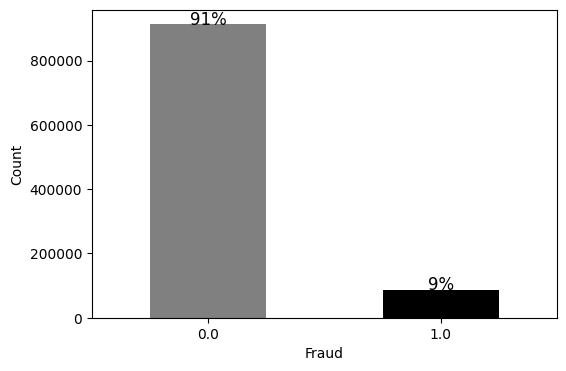

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# Nhập dữ liệu
fraud_trans = pd.read_csv('Chuong4/data/card_transdata.csv')

# Tính tỉ trọng phân bổ giữa 2 nhãn
flagged_fraud_counts = fraud_trans['fraud'].value_counts()
flagged_fraud_percentage = flagged_fraud_counts / flagged_fraud_counts.sum() * 100

# Trực quan
plt.figure(figsize=(6, 4))
ax = flagged_fraud_counts.plot(kind='bar', color=['grey', 'black'])

for i, count in enumerate(flagged_fraud_counts):
    percentage = flagged_fraud_percentage[i]
    ax.text(i, count + 50, f'{percentage:.0f}%', ha='center', fontsize=12)

plt.xlabel('Fraud')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()